In [1]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,Dropout
from keras import Sequential
from keras.datasets import mnist

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
X_test.shape

(10000, 28, 28)

Normalising Inputs

In [5]:
X_train=X_train/255
X_test=X_test/255

Implementing the Ann(Baseline)

In [6]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

Taking the Sparse_categorical_crossentropy because i did not encode the output values

In [7]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


In [9]:
history=model.fit(X_train,y_train,epochs=25,batch_size=64,validation_split=0.2)

Epoch 1/25
750/750 [==============================] - 2s 2ms/step - loss: 0.3118 - accuracy: 0.9096 - val_loss: 0.1615 - val_accuracy: 0.9522
Epoch 2/25
750/750 [==============================] - 1s 2ms/step - loss: 0.1271 - accuracy: 0.9620 - val_loss: 0.1152 - val_accuracy: 0.9642
Epoch 3/25
750/750 [==============================] - 1s 2ms/step - loss: 0.0883 - accuracy: 0.9730 - val_loss: 0.1093 - val_accuracy: 0.9677
Epoch 4/25
750/750 [==============================] - 1s 2ms/step - loss: 0.0665 - accuracy: 0.9794 - val_loss: 0.1154 - val_accuracy: 0.9657
Epoch 5/25
750/750 [==============================] - 1s 2ms/step - loss: 0.0516 - accuracy: 0.9842 - val_loss: 0.0948 - val_accuracy: 0.9733
Epoch 6/25
750/750 [==============================] - 1s 2ms/step - loss: 0.0400 - accuracy: 0.9876 - val_loss: 0.0994 - val_accuracy: 0.9712
Epoch 7/25
750/750 [==============================] - 1s 2ms/step - loss: 0.0322 - accuracy: 0.9894 - val_loss: 0.0946 - val_accuracy: 0.9744
Epoch 

In [10]:
y_prob=model.predict(X_test)
y_pred=y_prob.argmax(axis=1)

313/313 [==============================] - 0s 773us/step


In [11]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9792

Baseline Accuracy (0.979)

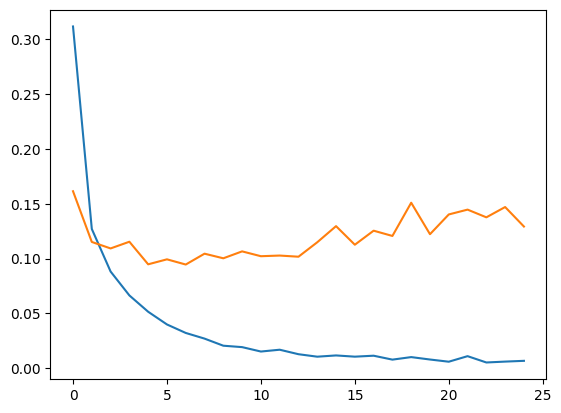

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

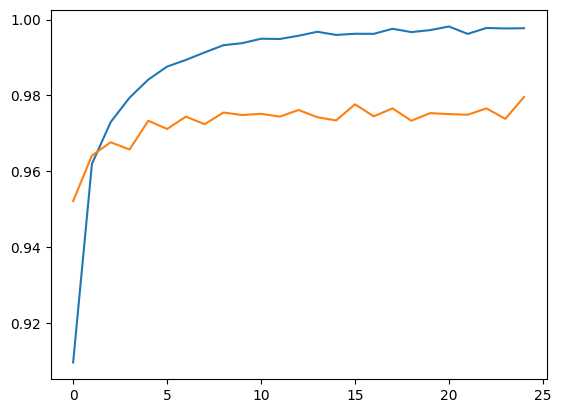

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Tuning the Ann

In [14]:
from keras.layers import BatchNormalization,Activation
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
model1=Sequential()
model1.add(Flatten(input_shape=(28,28)))
model1.add(Dense(128))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dropout(0.4))
model1.add(Dense(64,activation='relu'))
model1.add(BatchNormalization())
model1.add(Activation('relu'))
model1.add(Dropout(0.4))
model1.add(Dense(10,activation='softmax'))
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [15]:
model1.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [16]:
model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 128)               100480    
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128)               0         
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                      

In [17]:
history1=model1.fit(X_train,y_train,epochs=25,validation_split=0.2,batch_size=64,callbacks=[early_stop, lr_scheduler])

Epoch 1/25
750/750 [==============================] - 3s 3ms/step - loss: 0.6891 - accuracy: 0.7936 - val_loss: 0.2084 - val_accuracy: 0.9403 - lr: 0.0010
Epoch 2/25
750/750 [==============================] - 2s 3ms/step - loss: 0.3662 - accuracy: 0.8947 - val_loss: 0.1606 - val_accuracy: 0.9521 - lr: 0.0010
Epoch 3/25
750/750 [==============================] - 2s 3ms/step - loss: 0.3036 - accuracy: 0.9114 - val_loss: 0.1433 - val_accuracy: 0.9591 - lr: 0.0010
Epoch 4/25
750/750 [==============================] - 2s 3ms/step - loss: 0.2578 - accuracy: 0.9250 - val_loss: 0.1235 - val_accuracy: 0.9642 - lr: 0.0010
Epoch 5/25
750/750 [==============================] - 2s 3ms/step - loss: 0.2357 - accuracy: 0.9301 - val_loss: 0.1111 - val_accuracy: 0.9666 - lr: 0.0010
Epoch 6/25
750/750 [==============================] - 2s 3ms/step - loss: 0.2182 - accuracy: 0.9356 - val_loss: 0.1017 - val_accuracy: 0.9704 - lr: 0.0010
Epoch 7/25
750/750 [==============================] - 2s 3ms/step - lo

In [18]:
y_prob1=model.predict(X_test)
y_pred1=y_prob1.argmax(axis=1)
accuracy_score(y_test,y_pred1)

313/313 [==============================] - 0s 859us/step


0.9792

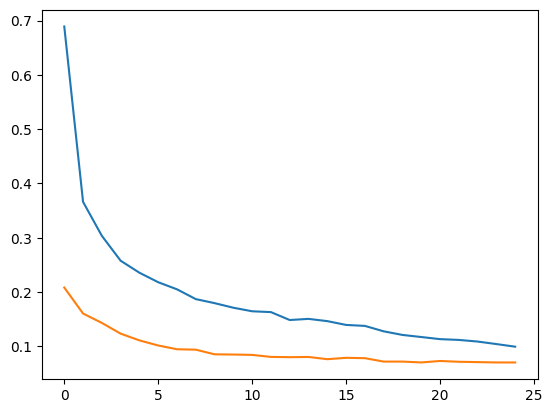

In [19]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

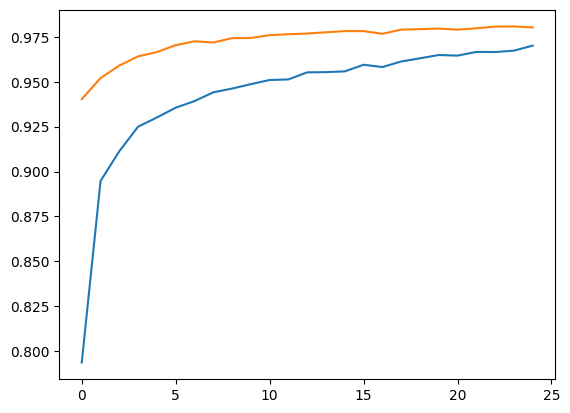

In [20]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

got the same test accuracy but in model 2 there is no overfitting but in model 1 there was overfitting